In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os


import seaborn as sns


# For venn diagram
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based


## Load RNA cell Barcodes from RNA-only modality CR analysis

In [2]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)


,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [ ]:
entropy_peaks_subdir = os.path.join(Union_cell_subdir, 'Entropy_cells_peaks')
entropy_peaks_gene_activity_file = os.path.join(entropy_peaks_subdir, 'DownstreamReanalysis', 'gene_activity_score.csv')
entropy_peaks_gene_activity = pd.read_csv(entropy_peaks_gene_activity_file, index_col=0).T

enough_frag_in_peaks_for_gene_activity = entropy_peaks_gene_activity.index.to_frame()
enough_frag_in_peaks_for_gene_activity['atac_bc'] = enough_frag_in_peaks_for_gene_activity.index.str.split('-').str[0]


In [23]:
union_cell_info['enough_frag_in_peaks_for_gene_activity'] = union_cell_info.index.isin(enough_frag_in_peaks_for_gene_activity['atac_bc'])

In [31]:
union_cell_info.groupby(['enough_frag_in_peaks_for_gene_activity', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
enough_frag_in_peaks_for_gene_activity,,
False,253,0
True,87,2044


# Venn comparison

In [25]:
no_RNA_no_enoughFrag_sub = union_cell_info.loc[~union_cell_info['rna_pass_CR'] & ~union_cell_info['enough_frag_in_peaks_for_gene_activity']].copy()

In [29]:
no_RNA_no_enoughFrag_sub.groupby(['atac_pass_CR', 'atac_pass_entropy']).size().unstack(fill_value=0)

atac_pass_entropy,False,True
atac_pass_CR,,
False,188,65


In [30]:
no_RNA_no_enoughFrag_sub.groupby(['atac_pass_archr_TSS', 'atac_pass_entropy']).size().unstack(fill_value=0)

atac_pass_entropy,False,True
atac_pass_archr_TSS,,
False,0,59
True,188,6


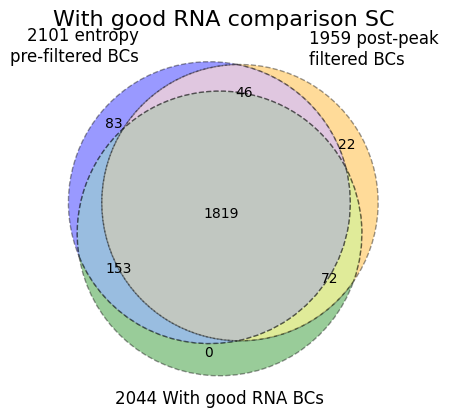

In [15]:

venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} With good RNA BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('With good RNA comparison SC', fontsize=16)
plt.show()

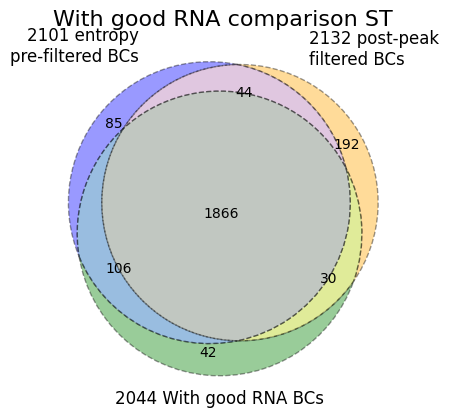

In [16]:

venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} With good RNA BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('With good RNA comparison ST', fontsize=16)
plt.show()

## On 

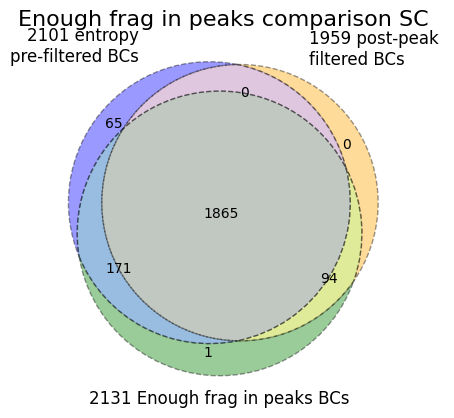

In [24]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['enough_frag_in_peaks_for_gene_activity']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} Enough frag in peaks BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('Enough frag in peaks comparison SC', fontsize=16)
plt.show()

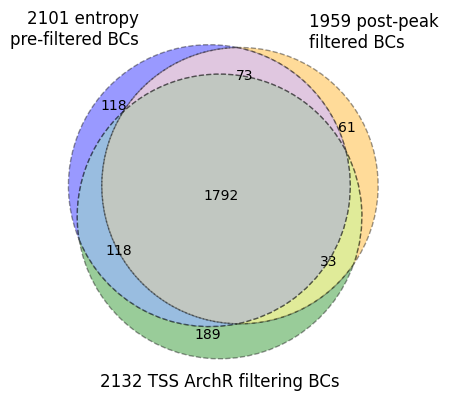

In [ ]:


venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} TSS ArchR filtering BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()

### Vis FRIP

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [71.52115430672441, 39.04932109935205, 57.83528387508196, 6.3600169978774685, 57.467556708310944, 25.254077041237682]
median 	 [72.53921585676142, 20.388349514563107, 67.89536266349585, 5.89307411907655, 69.89330024706359, 1.5151515151515151]


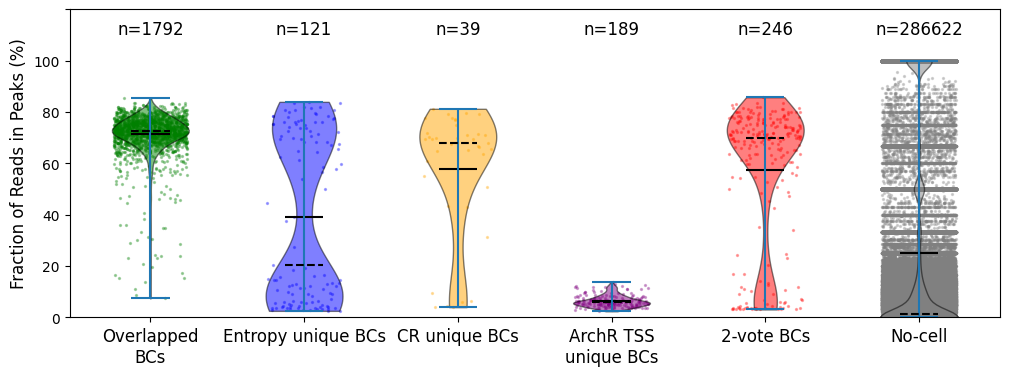

In [25]:
fig, ax = plt.subplots(figsize=(12, 4))

x_positions = range(6)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'purple', 'red', 'gray']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['identified_by_atac'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in 
               ['all', 'entropy_only', 'cr_only', 'archr_TSS_only', '2votes', 'none'] ]
total_counts = [a.shape[0] for a in frip_values]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy unique BCs', 'CR unique BCs', 'ArchR TSS\nunique BCs', '2-vote BCs', 'No-cell'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

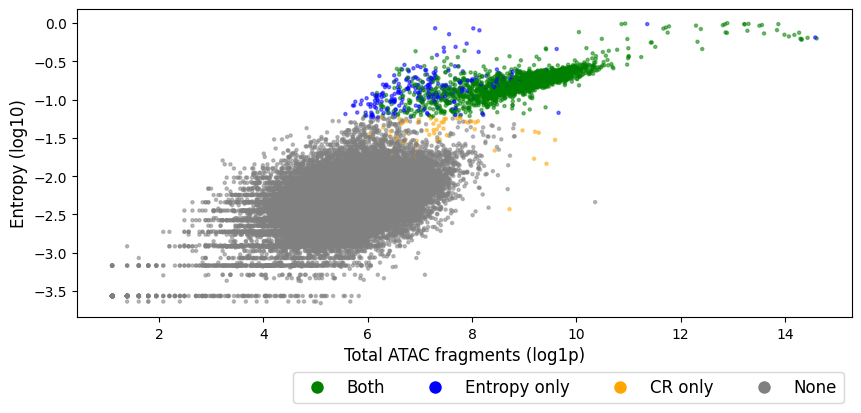

In [ ]:
fig, ax = plt.subplots( figsize=(10, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['_2set_identified_by_atac'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Total ATAC fragments (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Common',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='No-cell',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)

plt.show()

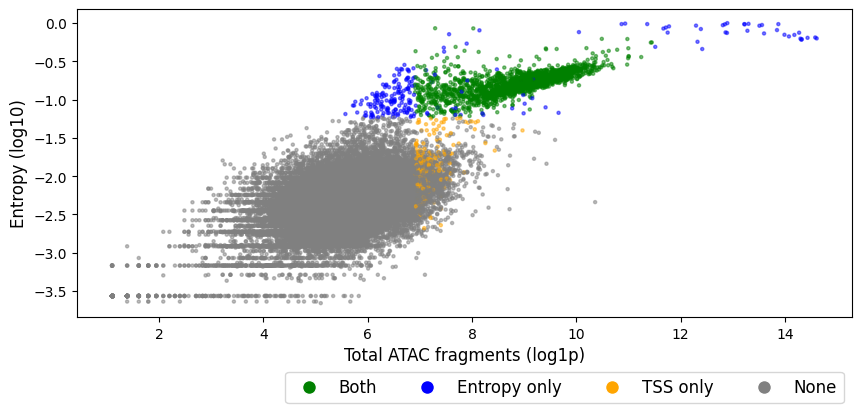

In [ ]:
fig, ax = plt.subplots( figsize=(10, 4) )
colors_map = {'both':'green', 'entropy_only':'blue', 'tss_only':'orange', 'none':'gray'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['_2set_identified_by_atac_ST'].map(colors_map), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(0.75, 0.5), loc='upper left')
ax.set_xlabel('Total ATAC fragments (log1p)', fontsize=12)
ax.set_ylabel('Entropy (log10)', fontsize=12)




ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Common',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='TSS only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='No-cell',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1, -0.15), loc='upper right', ncol=4, fontsize=12)


plt.show()

### How many barcoeds have invalid entropy values

In [28]:
total_frag_per_bc['invalid_entropy_value'] = ~total_frag_per_bc.index.isin(entropy_df.index)
total_frag_per_bc['invalid_entropy_value'].value_counts()

invalid_entropy_value
True     255722
False     33287
Name: count, dtype: int64

In [29]:
total_frag_per_bc.groupby(['invalid_entropy_value', 'identified_by_atac']).size().unstack()

identified_by_atac,2votes,all,archr_TSS_only,cr_only,entropy_only,none
invalid_entropy_value,,,,,,
False,245.0,1792.0,180.0,27.0,121.0,30922.0
True,1.0,NaN,9.0,12.0,NaN,255700.0


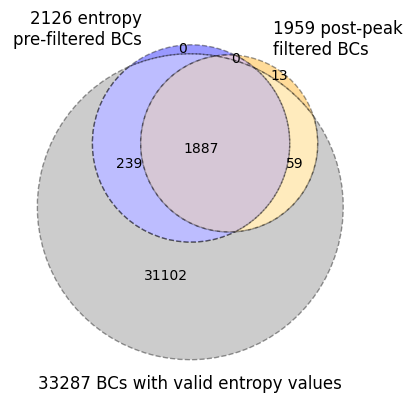

In [30]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based

venn_sets = {
    'Entropy pre-filtering BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    'CR post-peak filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    'valid entropy value BCs': set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
}

venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
)
fixed_sizes = (0.02, 0.02, 0.02, 2, 0.5, 0.2, 1) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} post-peak \nfiltered BCs', f'{len(venn_sets[2])} BCs with valid entropy values'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'grey'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()



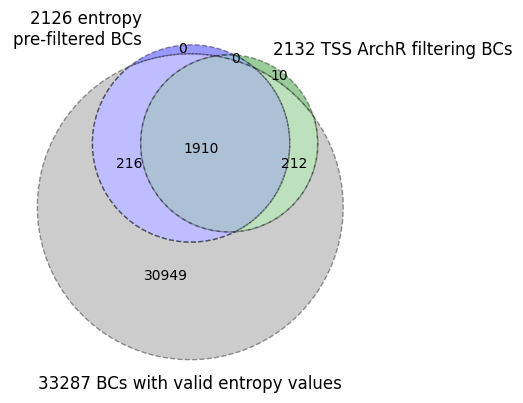

In [31]:

venn_sets = {
    'Entropy pre-filtering BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    'TSS ArchR filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index),
    'valid entropy value BCs': set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
}

venn_sets = (
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index),
    set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)   
)
fixed_sizes = (0.02, 0.02, 0.02, 2, 0.5, 0.2, 1) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} TSS ArchR filtering BCs', f'{len(venn_sets[2])} BCs with valid entropy values'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'green', 'grey'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')

plt.show()

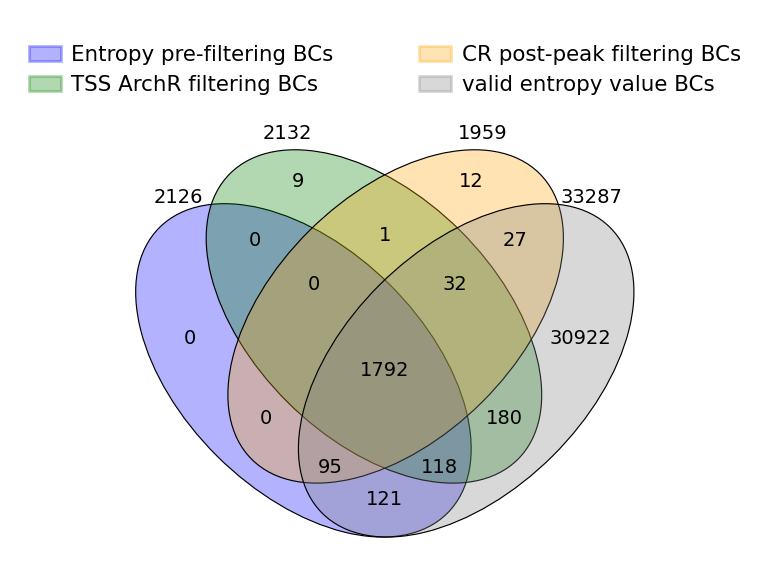

In [32]:
from venny4py.venny4py import *


venn_4sets = {
    'Entropy pre-filtering BCs':  set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_entropy']].index),
    'TSS ArchR filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_archr_TSS']].index),
    'CR post-peak filtering BCs': set(total_frag_per_bc.loc[total_frag_per_bc['atac_pass_CR']].index),
    'valid entropy value BCs': set(total_frag_per_bc.loc[~total_frag_per_bc['invalid_entropy_value']].index)
}


venny4py(sets=venn_4sets, colors=['blue', 'green', 'orange', 'grey'])
plt.show()

### ---

----- 	 both 	 entropy_only 	 tss_only (invalid entropy) 	 tss_only (valid entropy) 	 none
mean 	 [71.355, 40.854, 25.259, 12.67, 14.105]
median 	 [72.54, 46.249, 1.541, 6.524, 6.268]


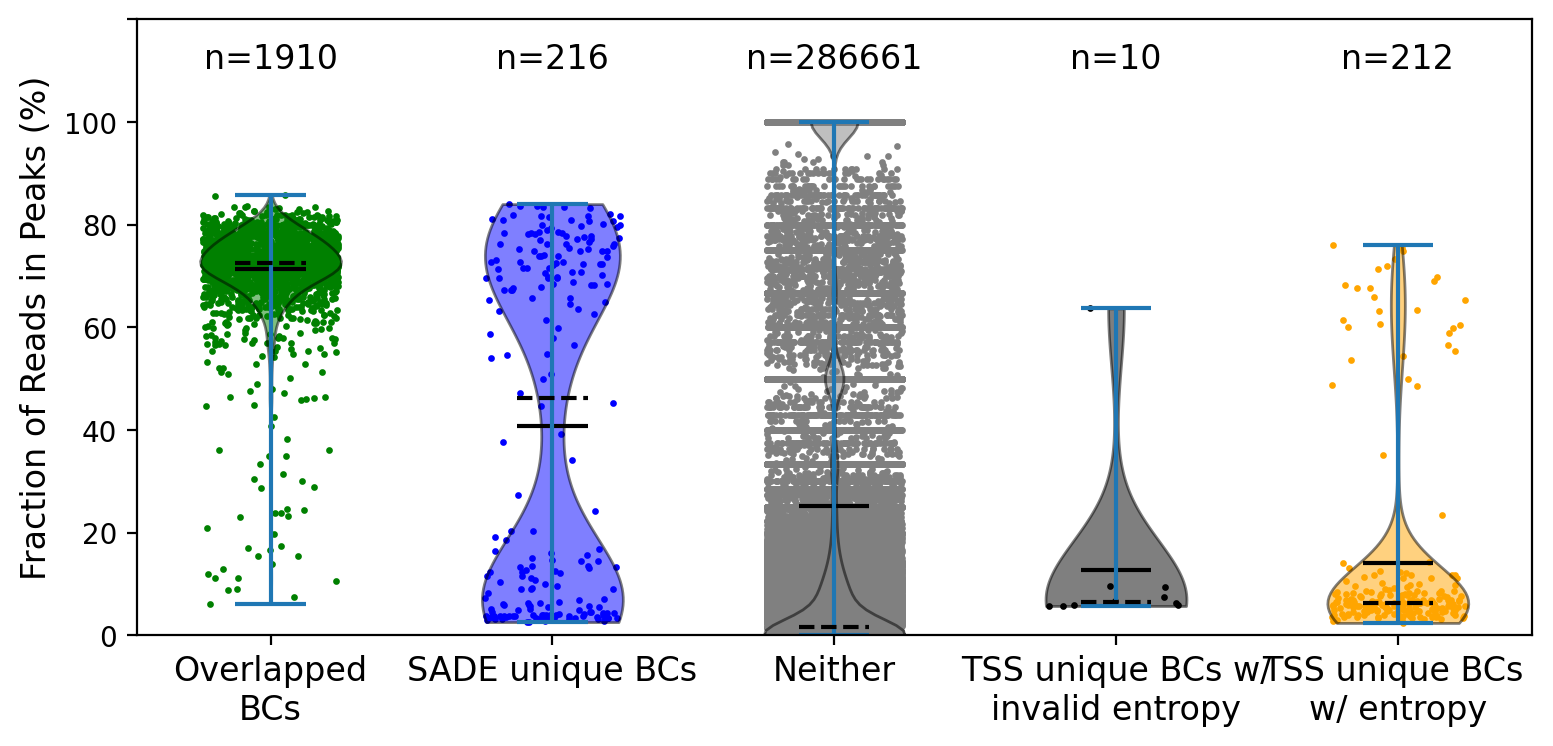

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))



colors_map = ['green', 'blue', 'gray', 'black', 'orange']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['_2set_identified_by_atac_ST'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in ['both', 'entropy_only',   'none'] ]
frip_values.append( 
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only') & (total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )
frip_values.append(
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only') & (~total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )

total_counts = [a.shape[0] for a in frip_values]
mean_frip_values = [np.round(np.mean(a), 3) for a in frip_values]
median_frip_values = [np.round(np.median(a), 3) for a in frip_values]


x_positions = range(len(frip_values))
width = 0.5

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=1, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'SADE unique BCs', 'Neither', 
                    'TSS unique BCs w/\ninvalid entropy', 'TSS unique BCs \nw/ entropy'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t tss_only (invalid entropy) \t tss_only (valid entropy) \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

----- 	 both 	 entropy_only 	 cr_only (invalid entropy) 	 cr_only (valid entropy) 	 none
mean 	 [70.093, 53.756, 25.242, 72.678, 54.672]
median 	 [72.426, 69.779, 1.695, 70.986, 63.244]


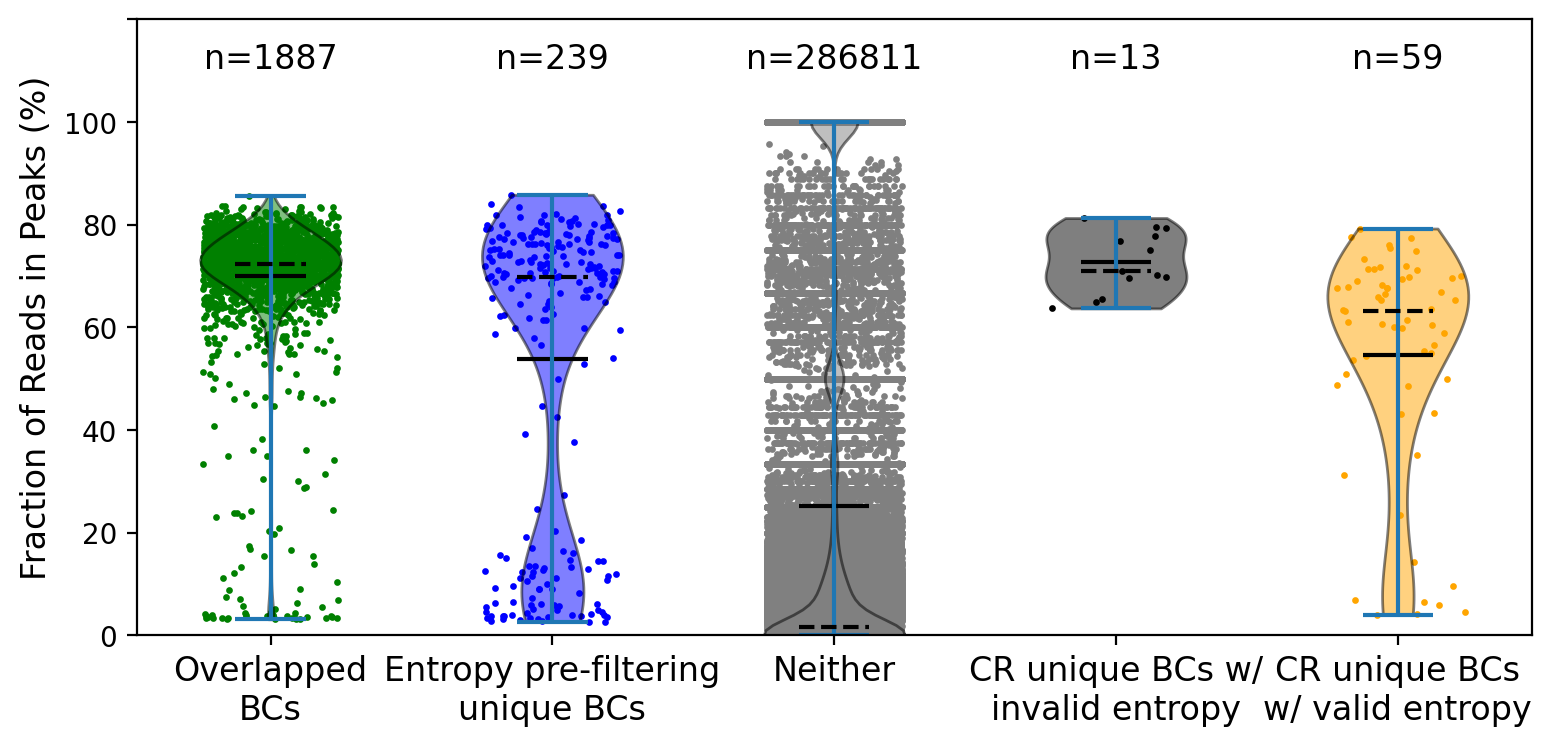

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))



colors_map = ['green', 'blue', 'gray', 'black', 'orange']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['_2set_identified_by_atac'] == cat, 'CRpeak_FRIP'].fillna(0) for cat in ['both', 'entropy_only',  'none'] ]
frip_values.append( 
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac'] == 'cr_only') & (total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )
frip_values.append(
                   total_frag_per_bc.loc[(total_frag_per_bc['_2set_identified_by_atac'] == 'cr_only') & (~total_frag_per_bc['invalid_entropy_value']),
                                          'CRpeak_FRIP'] )

total_counts = [a.shape[0] for a in frip_values]
mean_frip_values = [np.round(np.mean(a), 3) for a in frip_values]
median_frip_values = [np.round(np.median(a), 3) for a in frip_values]


x_positions = range(len(frip_values))
width = 0.5

# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=1, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy pre-filtering\nunique BCs', 'Neither', 
                    'CR unique BCs w/\ninvalid entropy', 'CR unique BCs\nw/ valid entropy'], rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.set_yticks(range(0, 121, 20))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only (invalid entropy) \t cr_only (valid entropy) \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

# Filter fragments by each category BCs

## Between SADE & CR

In [54]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['invalid_entropy_value'] & (total_frag_per_bc['identified_by_atac'] == 'cr_only')
].index.values
CR_unique_noEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [55]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['identified_by_atac'] == 'cr_only'
].index.values
CR_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]


In [56]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['identified_by_atac'] == 'cr_only' ) &
    (~total_frag_per_bc['invalid_entropy_value'])
].index.values

CR_unique_validEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [57]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['identified_by_atac'] == 'entropy_only'
].index.values
Entropy_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]


In [58]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['identified_by_atac'] == 'both')
].index.values

Overlap_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

Text(0.5, 1.0, 'CR unique BCs with invalid entropy values')

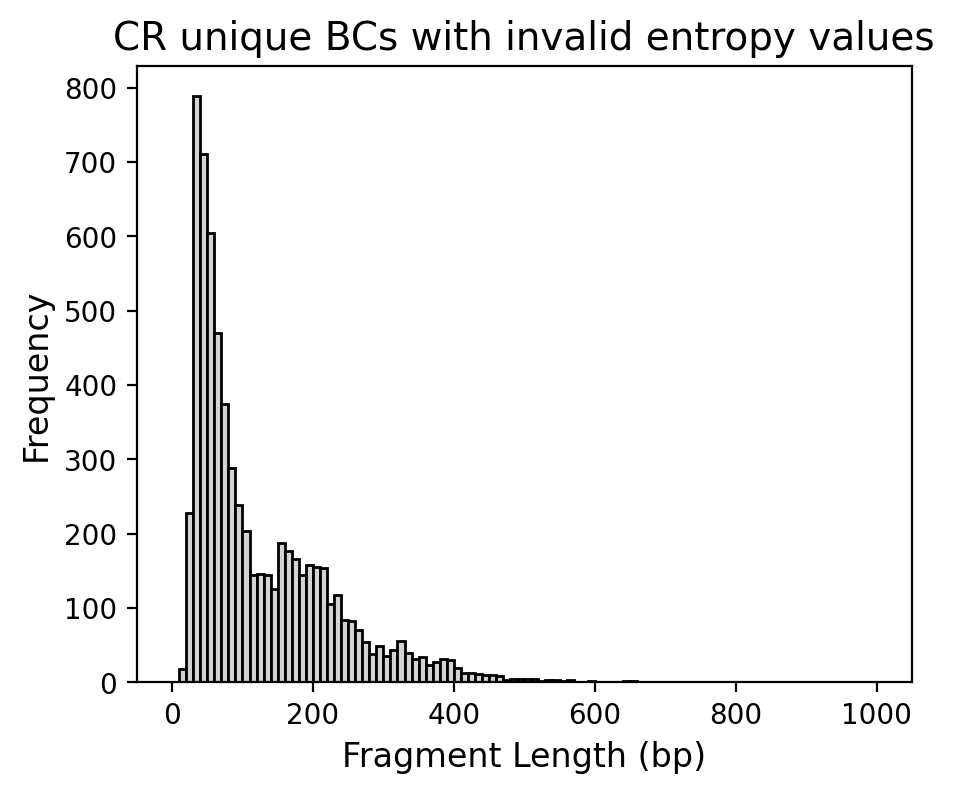

In [59]:


fig, ax = plt.subplots(figsize=(5, 4))
ax.hist( CR_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )
ax.set_xlabel('Fragment Length (bp)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('CR unique BCs with invalid entropy values', fontsize=14)

## Between SADE & TSS

In [62]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['invalid_entropy_value'] & (total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only')
].index.values
TSS_unique_noEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [63]:
bcs = total_frag_per_bc.loc[
    total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only'
].index.values
TSS_unique_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

In [64]:
bcs = total_frag_per_bc.loc[
    (total_frag_per_bc['_2set_identified_by_atac_ST'] == 'tss_only' ) &
    (~total_frag_per_bc['invalid_entropy_value'])
].index.values

TSS_unique_validEntropy_BC_frag = frag.loc[ frag['atac_bc'].isin(bcs) ]

# Calculate correlation with chromosome level fragment frequency

In [79]:
CRunique_chrom_counts = CR_unique_validEntropy_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
Overlapped_chrom_counts = Overlap_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
Entropyunique_chrom_counts = Entropy_unique_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)

for count in [CRunique_chrom_counts, Overlapped_chrom_counts, Entropyunique_chrom_counts]:
    # drop non-chromosome columns
    columns = [ col for col in count.columns if not col.startswith('chr') ]
    count.drop(columns=columns, inplace=True)

In [80]:
CRunique_BC_corr = pd.DataFrame( index=Overlapped_chrom_counts.index, columns=CRunique_chrom_counts.index )
chrom_names = Overlapped_chrom_counts.columns.values
for bc in CRunique_BC_corr.columns:
    CRunique_BC_corr[bc] = Overlapped_chrom_counts.T.corrwith( CRunique_chrom_counts.loc[bc, chrom_names], axis=0 )

In [81]:
Entropyunique_BC_corr = pd.DataFrame( index=Overlapped_chrom_counts.index, columns=Entropyunique_chrom_counts.index )
chrom_names = Overlapped_chrom_counts.columns.values
for bc in Entropyunique_BC_corr.columns:
    Entropyunique_BC_corr[bc] = Overlapped_chrom_counts.T.corrwith( Entropyunique_chrom_counts.loc[bc, chrom_names], axis=0 )

In [82]:
CRunique_BC_corr.head()

atac_bc,AAGCTAGGTTCTCACC,ACCTGGAAGAAAGGCA,ACGTCAACACGCCCAT,AGAATCTCATGAGCTA,ATAACCAAGTTAGGAC,ATGCGATAGTACTGAA,ATGTTGCGTAAGGCCG,ATGTTTGGTTTAATCG,CAAGTAATCTAACTGT,CAATGAGGTTTGGCTG,...,TAGCTAAAGCATCCTA,TATCCGGGTTATGGCT,TCAAACCGTAGGTGAC,TCAGGGATCCGCTAAC,TCCTGAGGTGGTTCTG,TCCTTTGGTTCCGGAC,TGATTGCGTCGGTTCA,TGGATCACAATTGACG,TGTTGCGGTAATTGGG,TTGAACCGTTCGGTAT
atac_bc,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,0.501159,0.878167,0.807948,0.897540,0.781836,0.911672,0.923540,0.771363,0.918147,0.764679,...,0.915989,0.879178,0.415422,0.325023,0.841162,0.733815,0.937424,0.725252,0.424223,0.748463
AAACAAGCATTTCTTC,0.075696,0.207193,0.417866,0.171815,0.140150,0.252068,0.105652,0.449896,0.205104,0.335927,...,0.021812,0.309582,0.115025,-0.090817,0.229183,0.103706,0.212866,0.033505,0.368569,0.032237
AAACCGCCAACGGTAC,0.440918,0.887922,0.794745,0.886531,0.777179,0.904097,0.915962,0.717528,0.893358,0.733507,...,0.922765,0.857136,0.418757,0.346276,0.802015,0.720874,0.913220,0.765421,0.318483,0.760677
AAACCGCCAGAAACCC,0.111379,0.699528,0.683647,0.607877,0.541515,0.829185,0.578455,0.650684,0.635250,0.575669,...,0.517794,0.682768,0.235588,0.290573,0.462284,0.491378,0.584195,0.608272,0.303695,0.484723
AAACGAACACCTGTAT,0.542016,0.898107,0.742021,0.881140,0.725180,0.911537,0.899886,0.827396,0.925291,0.821625,...,0.879963,0.940523,0.475428,0.313179,0.791095,0.773629,0.904714,0.798552,0.379159,0.761551


 ----- 	 CRunique 	 Entropyunique
Mean 	 0.7220 	 0.7977
Median 	 0.8091 	 0.9095


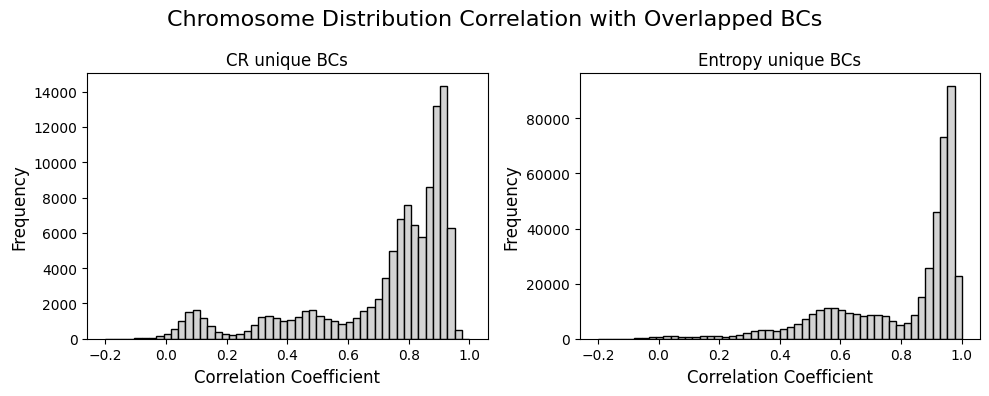

In [101]:
fig, ax = plt.subplots(ncols =2, figsize=(10, 4), sharey=False)

ax[0].hist( CRunique_BC_corr.values.flatten(), bins=50, range=(-0.2, 1.0), color='lightgray', edgecolor='black' )
ax[0].set_xlabel('Correlation Coefficient', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)
ax[0].set_title('CR unique BCs')

ax[1].hist( Entropyunique_BC_corr.values.flatten(), bins=50, range=(-0.2, 1.0), color='lightgray', edgecolor='black' )
ax[1].set_xlabel('Correlation Coefficient', fontsize=12)
ax[1].set_ylabel('Frequency', fontsize=12)
ax[1].set_title('Entropy unique BCs')
fig.suptitle('Chromosome Distribution Correlation with Overlapped BCs', fontsize=16)

fig.tight_layout()

mean_corr_CRunique = np.mean( CRunique_BC_corr.values.flatten() )
mean_corr_Entropyunique = np.mean( Entropyunique_BC_corr.values.flatten() )
median_corr_CRunique = np.median( CRunique_BC_corr.values.flatten() )
median_corr_Entropyunique = np.median( Entropyunique_BC_corr.values.flatten() )

print(f' ----- \t CRunique \t Entropyunique')
print(f'Mean \t {mean_corr_CRunique:.4f} \t {mean_corr_Entropyunique:.4f}')
print(f'Median \t {median_corr_CRunique:.4f} \t {median_corr_Entropyunique:.4f}')

/tmp/ipykernel_14837/3208045024.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax[1].set_xticklabels(chrom_counts.columns, rotation=45)


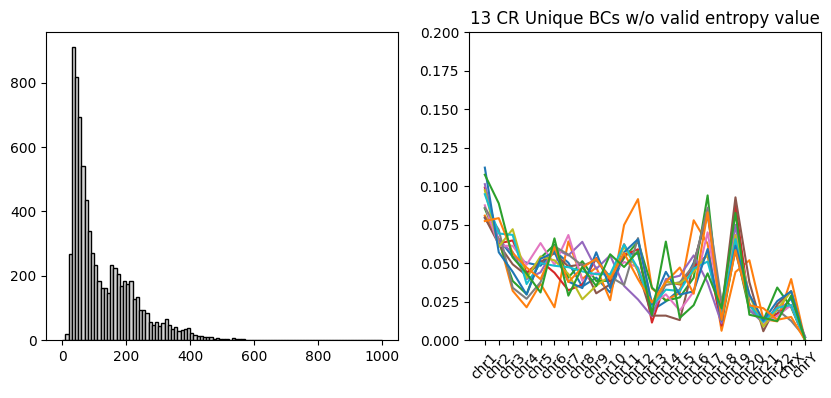

In [85]:
CRunique_noEntropy_chrom_counts = CR_unique_noEntropy_BC_frag.groupby(['atac_bc', 'chrom']).size().unstack().fillna(0)
CRunique_noEntropy_chrom_counts = CRunique_noEntropy_chrom_counts.drop( columns=[ col for col in CRunique_noEntropy_chrom_counts.columns if not col.startswith('chr') ] )

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 4) )

chrom_counts = CRunique_noEntropy_chrom_counts.reindex( sorted(CRunique_noEntropy_chrom_counts.columns, key=lambda x: (int(x[3:]) if x[3:].isdigit() else float('inf')) ), axis=1)

# line plot per barcode 
for idx, row in chrom_counts.iterrows():
    ax[1].plot( chrom_counts.columns, row / row.sum(),  )
ax[1].set_ylim(0, 0.2)
ax[1].set_title(f'{chrom_counts.shape[0]} CR Unique BCs w/o valid entropy value')
_ = ax[1].set_xticklabels(chrom_counts.columns, rotation=45)

_ = ax[0].hist( CR_unique_noEntropy_BC_frag['frag_length'], bins=100, range=(0, 1000), color='lightgray', edgecolor='black' )

## Active autosomes distribution

In [ ]:
chromo_freq_df = frag.loc[frag['atac_bc'].isin(total_frag_per_bc.index)].groupby(['atac_bc', 'chrom']).size().unstack(fill_value=0)


chr_chromo_freq_df = chromo_freq_df[[cname for cname in chromo_freq_df.columns if cname.startswith('chr')]]
nosex_chromo_freq_df = chr_chromo_freq_df[[cname for cname in chr_chromo_freq_df.columns if cname not in ['chrY', 'chrX']]]

a = total_frag_per_bc.join((nosex_chromo_freq_df > 0).sum(axis = 1).to_frame(name='active_number_chroms'), how='left')


fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

x_positions = range(4)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ a['active_number_chroms'].loc[ a['_2set_identified_by_atac_ST'] == cat ] for cat in ['both', 'tss_only', 'entropy_only', 'none'] ]
total_counts = [ frip.shape[0] for frip in frip_values ]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['both', 'tss_only', 'entropy_only', 'none'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Number of active non-sex chromosomes', fontsize=12)
ax.set_ylim(19, 25)
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

print('----- \t CR_2ndRound \t ArchR \t entropy_only')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

fig.suptitle('Distribution of Number of active non-sex chromosomes', fontsize=16)